In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, 
    confusion_matrix, f1_score
)
import joblib
import os


In [3]:
DATA_PATH = Path("../datasets/processed/labeled_complaints.csv")

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"\nCategory distribution:")
print(df['transaction_category'].value_counts())

# Use the cleaned text for training
df = df.dropna(subset=['complaint_text_clean', 'transaction_category'])
print(f"\n✅ Ready: {len(df):,} rows")

Dataset shape: (30000, 9)

Category distribution:
transaction_category
Service Not Provided        5000
Merchant Fraud              5000
Duplicate Charge            5000
Unauthorized Transaction    5000
Billing Error               5000
Goods Not Received          5000
Name: count, dtype: int64

✅ Ready: 30,000 rows


In [4]:
X = df['complaint_text_clean']
y = df['transaction_category']

# Encode labels to integers (sklearn needs this)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Label mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

# Train / validation / test split  (70 / 15 / 15)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_encoded, test_size=0.15, random_state=42, stratify=y_encoded
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
    # 0.176 of 85% ≈ 15% of total
)

print(f"\nSplit sizes:")
print(f"  Train : {len(X_train):,}  ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Val   : {len(X_val):,}  ({len(X_val)/len(X)*100:.0f}%)")
print(f"  Test  : {len(X_test):,}  ({len(X_test)/len(X)*100:.0f}%)")

Label mapping:
  0 → Billing Error
  1 → Duplicate Charge
  2 → Goods Not Received
  3 → Merchant Fraud
  4 → Service Not Provided
  5 → Unauthorized Transaction

Split sizes:
  Train : 21,012  (70%)
  Val   : 4,488  (15%)
  Test  : 4,500  (15%)


In [5]:
# TF-IDF converts text into numerical feature vectors
# max_features=20000 means we use the 20,000 most important words
# ngram_range=(1,2) means we also capture 2-word phrases like "unauthorized charge"

tfidf = TfidfVectorizer(
    max_features=20_000,
    ngram_range=(1, 2),        # unigrams + bigrams
    min_df=3,                  # ignore words appearing in fewer than 3 docs
    max_df=0.90,               # ignore words in more than 90% of docs (too common)
    sublinear_tf=True,         # apply log normalization to term frequencies
)

X_train_tfidf = tfidf.fit_transform(X_train)   # fit ONLY on train
X_val_tfidf   = tfidf.transform(X_val)          # transform val
X_test_tfidf  = tfidf.transform(X_test)         # transform test

print(f"✅ TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"   Each complaint is now a vector of {X_train_tfidf.shape[1]:,} features")

✅ TF-IDF matrix shape (train): (21012, 20000)
   Each complaint is now a vector of 20,000 features


In [6]:
print("Training Logistic Regression...")

lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,              # regularization strength (1.0 = default)
    solver='lbfgs',
    multi_class='multinomial',
    random_state=42,
    n_jobs=-1           # use all CPU cores
)

lr_model.fit(X_train_tfidf, y_train)

print("✅ Training complete!")

# Quick check on validation set
val_preds = lr_model.predict(X_val_tfidf)
val_acc   = accuracy_score(y_val, val_preds)
val_f1    = f1_score(y_val, val_preds, average='weighted')

print(f"\nValidation Results:")
print(f"  Accuracy : {val_acc*100:.2f}%")
print(f"  F1 Score : {val_f1*100:.2f}%")

Training Logistic Regression...
✅ Training complete!

Validation Results:
  Accuracy : 83.02%
  F1 Score : 82.87%


In [7]:
test_preds = lr_model.predict(X_test_tfidf)
test_acc   = accuracy_score(y_test, test_preds)
test_f1    = f1_score(y_test, test_preds, average='weighted')

print("=" * 55)
print("   BASELINE MODEL — TEST SET RESULTS")
print("=" * 55)
print(f"  Accuracy  : {test_acc*100:.2f}%")
print(f"  F1 Score  : {test_f1*100:.2f}%")
print()
print("Per-category breakdown:")
print(classification_report(
    y_test, test_preds,
    target_names=le.classes_
))

   BASELINE MODEL — TEST SET RESULTS
  Accuracy  : 82.44%
  F1 Score  : 82.29%

Per-category breakdown:
                          precision    recall  f1-score   support

           Billing Error       0.72      0.67      0.70       750
        Duplicate Charge       0.94      0.95      0.94       750
      Goods Not Received       0.87      0.92      0.89       750
          Merchant Fraud       0.82      0.77      0.79       750
    Service Not Provided       0.81      0.87      0.84       750
Unauthorized Transaction       0.78      0.76      0.77       750

                accuracy                           0.82      4500
               macro avg       0.82      0.82      0.82      4500
            weighted avg       0.82      0.82      0.82      4500



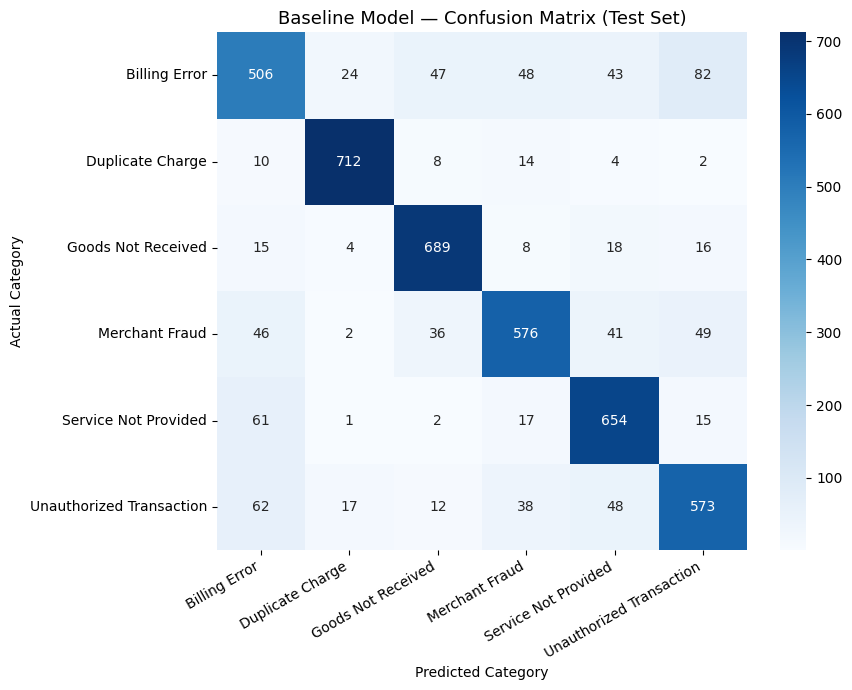

✅ Saved to docs/baseline_confusion_matrix.png


In [8]:
cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('Baseline Model — Confusion Matrix (Test Set)', fontsize=13)
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

os.makedirs('../docs', exist_ok=True)
plt.savefig('../docs/baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to docs/baseline_confusion_matrix.png")

In [9]:
# Show which words most strongly predict each category
# This is great for your project report and demo

feature_names = tfidf.get_feature_names_out()
top_n = 10

print("TOP PREDICTIVE WORDS PER CATEGORY")
print("=" * 55)

for i, category in enumerate(le.classes_):
    # Get the model's coefficients for this class
    coefs = lr_model.coef_[i]
    top_indices = coefs.argsort()[-top_n:][::-1]
    top_words = [feature_names[j] for j in top_indices]
    print(f"\n📂 {category}:")
    print(f"   {', '.join(top_words)}")

TOP PREDICTIVE WORDS PER CATEGORY

📂 Billing Error:
   return, usc, dispute, usc billing, billing, refund, credit card, billing errors, billing error, and got

📂 Duplicate Charge:
   duplicate, double, charged twice, twice, duplicated, double charged, charged, same charge, double charge, same

📂 Goods Not Received:
   not receive, never got, receive, delivered, not delivered, did not, never delivered, got, never arrived, did

📂 Merchant Fraud:
   never received, scam, misleading, scammed, received, never, scammers, scammer, received the, and misleading

📂 Service Not Provided:
   limit, the card, use, credit limit, declined, accounts, restricted, to use, verification, increase

📂 Unauthorized Transaction:
   fraudulent charges, fraudulent, fraudulent charge, not authorize, unauthorized, unauthorized charges, authorize, identity theft, unauthorized charge, fraud alert


In [10]:
def predict_dispute(text):
    """
    Given a raw complaint text, returns the predicted 
    dispute category and confidence score.
    """
    import re
    # Clean using same logic as notebook 01
    text_clean = text.lower()
    text_clean = re.sub(r'\bxx+\b', '', text_clean)
    text_clean = re.sub(r'\$[\d,]+\.?\d*', 'AMOUNT', text_clean)
    text_clean = re.sub(r'[^a-z\s]', ' ', text_clean)
    text_clean = re.sub(r'\s+', ' ', text_clean).strip()
    
    vec   = tfidf.transform([text_clean])
    pred  = lr_model.predict(vec)[0]
    probs = lr_model.predict_proba(vec)[0]
    
    category   = le.inverse_transform([pred])[0]
    confidence = probs.max() * 100
    
    print(f"Input     : {text[:120]}...")
    print(f"Predicted : {category}")
    print(f"Confidence: {confidence:.1f}%")
    print()
    all_probs = sorted(
        zip(le.classes_, probs * 100), 
        key=lambda x: -x[1]
    )
    print("All category scores:")
    for cat, prob in all_probs:
        bar = '█' * int(prob / 5)
        print(f"  {cat:<30} {prob:5.1f}%  {bar}")
    return category, confidence

# ── Test with sample complaints ──────────────────────────────────────────
print("TEST 1:")
predict_dispute(
    "I noticed a charge on my statement for $299 that I never made. "
    "Someone used my card without my permission at an online store."
)

print("\nTEST 2:")
predict_dispute(
    "I was charged twice for the same transaction on the same day. "
    "The merchant charged my card two times for the exact same purchase."
)

print("\nTEST 3:")
predict_dispute(
    "I ordered a laptop three months ago and never received it. "
    "The merchant stopped responding to my emails and the item never arrived."
)

TEST 1:
Input     : I noticed a charge on my statement for $299 that I never made. Someone used my card without my permission at an online s...
Predicted : Unauthorized Transaction
Confidence: 53.6%

All category scores:
  Unauthorized Transaction        53.6%  ██████████
  Billing Error                   32.2%  ██████
  Duplicate Charge                 5.0%  █
  Merchant Fraud                   4.2%  
  Service Not Provided             2.7%  
  Goods Not Received               2.2%  

TEST 2:
Input     : I was charged twice for the same transaction on the same day. The merchant charged my card two times for the exact same ...
Predicted : Duplicate Charge
Confidence: 99.8%

All category scores:
  Duplicate Charge                99.8%  ███████████████████
  Billing Error                    0.2%  
  Unauthorized Transaction         0.0%  
  Service Not Provided             0.0%  
  Merchant Fraud                   0.0%  
  Goods Not Received               0.0%  

TEST 3:
Input     : I or

('Merchant Fraud', np.float64(94.16146554732562))

In [11]:
MODEL_DIR = Path("../backend/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save model
joblib.dump(lr_model, MODEL_DIR / "baseline_lr_model.pkl")

# Save vectorizer — must be saved together with the model
joblib.dump(tfidf, MODEL_DIR / "tfidf_vectorizer.pkl")

# Save label encoder — needed to decode predictions back to category names
joblib.dump(le, MODEL_DIR / "label_encoder.pkl")

print("✅ Model artifacts saved:")
print(f"   {MODEL_DIR}/baseline_lr_model.pkl")
print(f"   {MODEL_DIR}/tfidf_vectorizer.pkl")
print(f"   {MODEL_DIR}/label_encoder.pkl")

✅ Model artifacts saved:
   ../backend/models/baseline_lr_model.pkl
   ../backend/models/tfidf_vectorizer.pkl
   ../backend/models/label_encoder.pkl


In [ ]:
print("=" * 55)
print("   NOTEBOOK 03 — BASELINE MODEL COMPLETE")
print("=" * 55)
print(f"""
Model  : Logistic Regression + TF-IDF
Classes: {len(le.classes_)} dispute categories
Train  : {len(X_train):,} samples
Test   : {len(X_test):,} samples

Results:
  Test Accuracy : {test_acc*100:.2f}%
  Test F1 Score : {test_f1*100:.2f}%

Saved to backend/models/:
  ├── baseline_lr_model.pkl
  ├── tfidf_vectorizer.pkl
  └── label_encoder.pkl
""")

   NOTEBOOK 03 — BASELINE MODEL COMPLETE

Model  : Logistic Regression + TF-IDF
Classes: 6 dispute categories
Train  : 21,012 samples
Test   : 4,500 samples

Results:
  Test Accuracy : 82.44%
  Test F1 Score : 82.29%

Saved to backend/models/:
  ├── baseline_lr_model.pkl
  ├── tfidf_vectorizer.pkl
  └── label_encoder.pkl

🔜 Next: 04_bert_model.ipynb (deep learning upgrade)

